In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
import gymnasium as gym
import ale_py
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecFrameStack
from stable_baselines3.common.atari_wrappers import AtariWrapper
from stable_baselines3.common.callbacks import BaseCallback
 
gym.register_envs(ale_py)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## Environment inspection 

In [ ]:
env = gym.make("ALE/MsPacman-v5")
obs, info = env.reset()

print("SPACES")
print("Obs space:", env.observation_space)
print("Act space:", env.action_space)
print("Actions:", env.unwrapped.get_action_meanings())

print("\n INFO DICT KEYS")
print(info)

print("\n ALE PROPERTIES")
ale = env.unwrapped.ale
print("Lives:", ale.lives())
print("Frame number:", ale.getFrameNumber())
print("Episode frames:", ale.getEpisodeFrameNumber())
print("RAM size:", len(ale.getRAM()))
print("Legal actions:", ale.getLegalActionSet())
print("Min actions:", ale.getMinimalActionSet())

env.close()

=== SPACES ===
Obs space: Box(0, 255, (210, 160, 3), uint8)
Act space: Discrete(9)
Actions: ['NOOP', 'UP', 'RIGHT', 'LEFT', 'DOWN', 'UPRIGHT', 'UPLEFT', 'DOWNRIGHT', 'DOWNLEFT']

=== INFO DICT KEYS ===
{'lives': 3, 'episode_frame_number': 0, 'frame_number': 0}

=== ALE PROPERTIES ===
Lives: 3
Frame number: 0
Episode frames: 0
RAM size: 128
Legal actions: [<Action.NOOP: 0>, <Action.FIRE: 1>, <Action.UP: 2>, <Action.RIGHT: 3>, <Action.LEFT: 4>, <Action.DOWN: 5>, <Action.UPRIGHT: 6>, <Action.UPLEFT: 7>, <Action.DOWNRIGHT: 8>, <Action.DOWNLEFT: 9>, <Action.UPFIRE: 10>, <Action.RIGHTFIRE: 11>, <Action.LEFTFIRE: 12>, <Action.DOWNFIRE: 13>, <Action.UPRIGHTFIRE: 14>, <Action.UPLEFTFIRE: 15>, <Action.DOWNRIGHTFIRE: 16>, <Action.DOWNLEFTFIRE: 17>]
Min actions: [<Action.NOOP: 0>, <Action.UP: 2>, <Action.RIGHT: 3>, <Action.LEFT: 4>, <Action.DOWN: 5>, <Action.UPRIGHT: 6>, <Action.UPLEFT: 7>, <Action.DOWNRIGHT: 8>, <Action.DOWNLEFT: 9>]


In [3]:
import torch
print(torch.__version__)        
print(torch.cuda.is_available()) 

2.6.0+cu124
True


## Reward Shaping Wrapper

In [4]:
class RewardShapingWrapper(gym.Wrapper):
    GHOST_REWARDS = {200, 400, 800, 1600}
    FRUIT_REWARDS = {100, 300, 500, 700, 1000, 2000, 3000, 5000}
    POWER_PELLET_REWARD = 50
    REGULAR_PELLET_REWARD = 10
    POWER_PELLET_DURATION = 150  
 
    def __init__(
        self,
        env,
        ghost_chain_bonus = 12.0,
        pellet_streak_bonus = 0.03,
        fruit_multiplier = 1.05,
        death_penalty = 0.0,
    ):
        super().__init__(env)
        self.ghost_chain_bonus = ghost_chain_bonus
        self.pellet_streak_bonus = pellet_streak_bonus
        self.fruit_multiplier = fruit_multiplier
        self.death_penalty = death_penalty
 
        # Mutable state
        self._prev_lives = None
        self.ghosts_eaten = 0     
        self._pellet_streak = 0
        self._steps_since_pellet = 0
        self._power_pellet_active = False
        self._power_pellet_steps = 0
 
    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self._prev_lives = None
        self.ghosts_eaten = 0
        self._pellet_streak = 0
        self._steps_since_pellet = 0
        self._power_pellet_active = False
        self._power_pellet_steps = 0
        return obs, info
 
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        shaped_reward = reward
        raw = int(reward)
 
        # Life tracker initialisation
        current_lives = info.get("lives", 3)
        if self._prev_lives is None:
            self._prev_lives = current_lives
 
        # Power-pellet window bookkeeping
        if self._power_pellet_active:
            self._power_pellet_steps += 1
            if self._power_pellet_steps > self.POWER_PELLET_DURATION:
                self._power_pellet_active = False
                self._power_pellet_steps = 0
                self.ghosts_eaten = 0
 
        # Ghost chain bonus
        if raw in self.GHOST_REWARDS:
            self.ghosts_eaten += 1
            if self.ghosts_eaten > 1:
                shaped_reward += self.ghost_chain_bonus * (self.ghosts_eaten - 1)
 
        # Pellet streak
        if raw == self.REGULAR_PELLET_REWARD:
            self._pellet_streak += 1
            self._steps_since_pellet = 0
            shaped_reward += self.pellet_streak_bonus * self._pellet_streak
 
        elif raw == self.POWER_PELLET_REWARD:
            self._pellet_streak += 1
            self._steps_since_pellet = 0
            shaped_reward += self.pellet_streak_bonus * self._pellet_streak
            self._power_pellet_active = True
            self._power_pellet_steps = 0
            self.ghosts_eaten = 0
 
        else:
            self._steps_since_pellet += 1
            if self._steps_since_pellet > 8:
                self._pellet_streak = 0
 
        # Fruit multiplier 
        if raw in self.FRUIT_REWARDS:
            shaped_reward += (self.fruit_multiplier - 1.0) * raw
 
        # Death penalty
        if current_lives < self._prev_lives:
            shaped_reward += self.death_penalty
        self._prev_lives = current_lives
 
        return obs, shaped_reward, terminated, truncated, info
    

## Experimental Conditions

In [ ]:
CONDITIONS = {
    "Baseline": {
        "wrapper": None,
        "color": "blue",
        "description": "Default ALE rewards only",
    },
    "Expert Shaping": {
        "wrapper": "expert",
        "ghost_chain_bonus": 12.0,
        "pellet_streak_bonus": 0.0,
        "fruit_multiplier": 1.5,
        "death_penalty": 0.0,
        "color": "orange",
        "description": "Chain + fruit, no elimination penalty",
    },
    "Expert Shaping + Elimination Penalty": {
        "wrapper": "expert",
        "ghost_chain_bonus": 12.0,
        "pellet_streak_bonus": 0.0,
        "fruit_multiplier": 1.5,
        "death_penalty": -1.0,
        "color": "purple",
        "description": "Chain + fruit + elimination penalty",
    },
}
 
print("Conditions defined:")
for name, cfg in CONDITIONS.items():
    print(f"{name:35s} - {cfg['description']}")
    

Conditions defined:
  Baseline                            — Default ALE rewards only
  Expert Shaping                      — Chain + fruit, no death penalty
  Expert Shaping + Death Penalty      — Chain + fruit + death penalty


## Progress Callback (tracks metrics per episode)

In [ ]:
class ExperimentCallback(BaseCallback):
    def __init__(self, condition_name, verbose= 0):
        super().__init__(verbose)
        self.condition_name = condition_name
        self.episode_rewards = []  
        self.episode_shaped_rewards = []  
        self.episode_lengths = []
        self.episode_ghosts_eaten = []
 
        self._shaped_accum = 0.0
        self._length_accum = 0
 
    def _on_step(self):
        self._shaped_accum += float(self.locals["rewards"][0])
        self._length_accum += 1
 
        if self.locals["dones"][0]:
            info = self.locals["infos"][0]
            # True unshaped score 
            true_r = info.get("episode", {}).get("r", self._shaped_accum)
            # Retrieve ghosts_eaten from the innermost wrapper that has it.
            inner_env = self.training_env.envs[0]
            while hasattr(inner_env, "env"):
                if hasattr(inner_env, "ghosts_eaten"):
                    break
                inner_env = inner_env.env
            ghosts = getattr(inner_env, "ghosts_eaten", 0)
 
            self.episode_rewards.append(float(true_r))
            self.episode_shaped_rewards.append(float(self._shaped_accum))
            self.episode_lengths.append(int(self._length_accum))
            self.episode_ghosts_eaten.append(int(ghosts))
 
            n = len(self.episode_rewards)
            if n % 50 == 0:
                w = min(20, n)
                print(
                    f"  [{self.condition_name}] Ep {n:>4} | "
                    f"Steps {self.num_timesteps:>8,} | "
                    f"True: {np.mean(self.episode_rewards[-w:]):>7.1f} | "
                    f"Shaped: {np.mean(self.episode_shaped_rewards[-w:]):>7.1f} | "
                    f"Len: {np.mean(self.episode_lengths[-w:]):>5.0f}"
                )
 
            self._shaped_accum = 0.0
            self._length_accum = 0
 
        return True
    

## Training Function

In [7]:
def make_env(condition_cfg, seed=42):
    def _init():
        env = gym.make("ALE/MsPacman-v5", render_mode=None)
        if condition_cfg.get("wrapper") == "expert":
            env = RewardShapingWrapper(
                env,
                ghost_chain_bonus = condition_cfg.get("ghost_chain_bonus", 0.0),
                pellet_streak_bonus = condition_cfg.get("pellet_streak_bonus", 0.0),
                fruit_multiplier = condition_cfg.get("fruit_multiplier", 1.0),
                death_penalty = condition_cfg.get("death_penalty", 0.0),
            )
        env = AtariWrapper(env, clip_reward=False)
        env.reset(seed=seed)
        return env
 
    return _init
 
def train_condition(condition_name, condition_cfg, total_timesteps = 1_000_000, seed = 42):
    print(f"\n{'='*62}")
    print(f"Training: {condition_name}")
    print(f"Config: {condition_cfg['description']}")
    print(f"Steps: {total_timesteps:,}, Seed: {seed}")
 
    vec_env = DummyVecEnv([make_env(condition_cfg, seed)])
    vec_env = VecFrameStack(vec_env, n_stack=4)
 
    model = PPO(
        "CnnPolicy",
        vec_env,
        n_steps = 128,
        batch_size = 256,
        n_epochs = 4,
        gamma = 0.99,
        learning_rate = 2.5e-4,
        clip_range = 0.1,
        verbose = 0,
        seed = seed,
    )
 
    callback = ExperimentCallback(condition_name)
    model.learn(total_timesteps=total_timesteps, callback=callback)
 
    steps_str = f"{total_timesteps // 1_000_000}M"
    file_name = "_".join(condition_name.replace("+", "").lower().split())
    save_path = f"ppo_pacman_{file_name}_{steps_str}_seed{seed}"
 
    model.save(save_path)
    print(f"  Model saved: {save_path}.zip")
 
    log_path = f"training_{file_name}_{steps_str}_seed{seed}.json"
    with open(log_path, "w") as f:
        json.dump({
            "condition": condition_name,
            "seed": seed,
            "total_steps": total_timesteps,
            "episode_rewards": callback.episode_rewards,
            "episode_shaped_rewards": callback.episode_shaped_rewards,
            "episode_lengths": callback.episode_lengths,
            "episode_ghosts_eaten": callback.episode_ghosts_eaten,
        }, f)
    print(f"  Training log: {log_path}")
 
    vec_env.close()
    return model, callback


## Train Loop for 1_000_000 steps * 3 seeds

In [8]:
SEED_SHORT = [42, 99, 123]
TOTAL_STEPS_SHORT = 1_000_000
TOTAL_STEPS_MID = 3_000_000
TOTAL_STEPS_LONG = 7_000_000
SEED_MID = 42
SEED_LONG = 42

In [11]:
results_multiseed = {name: [] for name in CONDITIONS}

for name, cfg in CONDITIONS.items():
    for seed in SEED_SHORT:
        try:
            model, callback = train_condition(name, cfg, total_timesteps=TOTAL_STEPS_SHORT, seed=seed)
            results_multiseed[name].append({
                "seed": seed,
                "model": model,
                "episode_rewards": callback.episode_rewards,
                "episode_shaped_rewards": callback.episode_shaped_rewards,
                "episode_lengths": callback.episode_lengths,
                "episode_ghosts_eaten": callback.episode_ghosts_eaten,
                "total_steps": TOTAL_STEPS_SHORT,
            })
            print(f"{name} with seed {seed} complete.")
        except Exception as exc:
            print(f"{name} with seed {seed} failed: {exc}")
            results_multiseed[name].append(None)

print(f"\nAll conditions trained {TOTAL_STEPS_SHORT:,} steps each.")



Training: Baseline
Config: Default ALE rewards only
Steps: 1,000,000, Seed: 42


g:\PacManRLTraining\.venv\Lib\site-packages\stable_baselines3\ppo\ppo.py:155: UserWarning: You have specified a mini-batch size of 256, but because the `RolloutBuffer` is of size `n_steps * n_envs = 128`, after every 0 untruncated mini-batches, there will be a truncated mini-batch of size 128
We recommend using a `batch_size` that is a factor of `n_steps * n_envs`.
Info: (n_steps=128 and n_envs=1)
  warnings.warn(


  [Baseline] Ep   50 | Steps    2,442 | True:   199.0 | Shaped:   199.0 | Len:    57
  [Baseline] Ep  100 | Steps    5,198 | True:   136.0 | Shaped:   136.0 | Len:    54
  [Baseline] Ep  150 | Steps    7,854 | True:   131.5 | Shaped:   131.5 | Len:    50
  [Baseline] Ep  200 | Steps   10,574 | True:   166.5 | Shaped:   166.5 | Len:    49
  [Baseline] Ep  250 | Steps   13,221 | True:   186.0 | Shaped:   186.0 | Len:    55
  [Baseline] Ep  300 | Steps   15,885 | True:   156.0 | Shaped:   156.0 | Len:    55
  [Baseline] Ep  350 | Steps   18,519 | True:   196.5 | Shaped:   196.5 | Len:    58
  [Baseline] Ep  400 | Steps   21,117 | True:   152.0 | Shaped:   152.0 | Len:    51
  [Baseline] Ep  450 | Steps   23,688 | True:   135.0 | Shaped:   135.0 | Len:    50
  [Baseline] Ep  500 | Steps   25,940 | True:   109.0 | Shaped:   109.0 | Len:    47
  [Baseline] Ep  550 | Steps   28,506 | True:   256.0 | Shaped:   256.0 | Len:    57
  [Baseline] Ep  600 | Steps   31,236 | True:   408.0 | Shaped:  

## Training loop for 3_000_000 steps

In [ ]:
results_mid= {}

for name, cfg in CONDITIONS.items():
        try:
            model, callback = train_condition(name, cfg, total_timesteps=TOTAL_STEPS_MID, seed=SEED_MID)
            results_mid[name] = {
                "seed": SEED_MID,
                "model": model,
                "episode_rewards": callback.episode_rewards,
                "episode_shaped_rewards": callback.episode_shaped_rewards,
                "episode_lengths": callback.episode_lengths,
                "episode_ghosts_eaten": callback.episode_ghosts_eaten,
                "total_steps": TOTAL_STEPS_MID,
            }
            print(f"Mid run: {name} complete.")
        except Exception as exc:
            print(f"Mid run: {name} failed: {exc}")
            results_mid[name] = None

print(f"\nAll conditions trained {TOTAL_STEPS_MID:,} steps each.")


## Training loop for 7_000_000

In [ ]:
results_long = {}

for name, cfg in CONDITIONS.items():
        try:
            model, callback = train_condition(name, cfg, total_timesteps=TOTAL_STEPS_LONG, seed=SEED_LONG)
            results_long[name] = {
                "seed": SEED_LONG,
                "model": model,
                "episode_rewards": callback.episode_rewards,
                "episode_shaped_rewards": callback.episode_shaped_rewards,
                "episode_lengths": callback.episode_lengths,
                "episode_ghosts_eaten": callback.episode_ghosts_eaten,
                "total_steps": TOTAL_STEPS_LONG,
            }
            print(f"Long run: {name} complete.")
        except Exception as exc:
            print(f"Long run: {name} failed: {exc}")
            results_long[name] = None

print(f"\nAll conditions trained {TOTAL_STEPS_LONG:,} steps each.")


## Evaluation Function

In [12]:
def evaluate_agent(model, n_episodes=100, seed=99):
    def _make_eval_env():
        env = gym.make("ALE/MsPacman-v5")
        env = AtariWrapper(env, clip_reward=False)
        env.reset(seed=seed)
        return env
 
    eval_env = DummyVecEnv([_make_eval_env])
    eval_env = VecFrameStack(eval_env, n_stack=4)
 
    GHOST_REWARD_VALUES = {200, 400, 800, 1600}
 
    scores, lengths, ghost_chains, ghosts_eaten, score_per_step = [], [], [], [], []
 
    for _ in range(n_episodes):
        obs = eval_env.reset()
        total_score = 0.0
        length = 0
        done  = False
        current_chain = 0
        max_chain = 0
        ep_ghosts = 0
        prev_lives = 3
 
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done_arr, info = eval_env.step(action)
            done = bool(done_arr[0])
            r = float(reward[0])
            total_score += r
            length      += 1
 
            # Ghost chain tracking 
            raw_r = int(round(r))
            if raw_r in GHOST_REWARD_VALUES:
                current_chain += 1
                max_chain = max(max_chain, current_chain)
                ep_ghosts += 1
            # power pellet resets chain
            elif raw_r == 50:         
                current_chain = 0
 
            # Death resets chain
            current_lives = info[0].get("lives", prev_lives)
            if current_lives < prev_lives:
                current_chain = 0
            prev_lives = current_lives
 
        scores.append(total_score)
        lengths.append(length)
        ghost_chains.append(max_chain)
        ghosts_eaten.append(ep_ghosts)
        score_per_step.append(total_score / length if length > 0 else 0.0)
 
    eval_env.close()
 
    return {
        "scores": np.array(scores),
        "lengths": np.array(lengths),
        "ghost_chains": np.array(ghost_chains),
        "ghosts_eaten": np.array(ghosts_eaten),
        "score_per_step": np.array(score_per_step),
    }


## Evaluate Multi_Seed

In [ ]:
eval_results_multiseed = {name: [] for name in CONDITIONS}

for name, seed_runs in results_multiseed.items():
    for run in seed_runs:
        if run is None:
            continue
        seed = run["seed"]
        print(f"Evaluating {name} — seed {seed} ...")
        er = evaluate_agent(run["model"], n_episodes=100, seed=99)
        eval_results_multiseed[name].append({"seed": seed, **er})

        model  = "_".join(name.replace("+", "").lower().split())
        save_name = f"eval_{model}_1M_seed{seed}.json"
        with open(save_name, "w") as f:
            json.dump(
                {k: v.tolist() for k, v in er.items()} |
                {"condition": name, "steps": TOTAL_STEPS_SHORT, "seed": seed},
                f,
            )
        print(f"  Saved → {save_name}")

Evaluating Baseline — seed 42 ...
  Saved → eval_baseline_1M_seed42.json
Evaluating Baseline — seed 99 ...
  Saved → eval_baseline_1M_seed99.json
Evaluating Baseline — seed 123 ...
  Saved → eval_baseline_1M_seed123.json
Evaluating Expert Shaping — seed 42 ...
  Saved → eval_expert_shaping_1M_seed42.json
Evaluating Expert Shaping — seed 99 ...
  Saved → eval_expert_shaping_1M_seed99.json
Evaluating Expert Shaping — seed 123 ...
  Saved → eval_expert_shaping_1M_seed123.json
Evaluating Expert Shaping + Death Penalty — seed 42 ...
  Saved → eval_expert_shaping_death_penalty_1M_seed42.json
Evaluating Expert Shaping + Death Penalty — seed 99 ...
  Saved → eval_expert_shaping_death_penalty_1M_seed99.json
Evaluating Expert Shaping + Death Penalty — seed 123 ...
  Saved → eval_expert_shaping_death_penalty_1M_seed123.json


,Avg Score,Std,Survival,Ghost Chain,Ghosts/ep,Score/step
Baseline,171.2,146.4,46.9,0.03,0.0,3.285
Expert Shaping,145.8,128.9,44.3,0.04,0.0,3.112
Expert Shaping + Death Penalty,125.2,152.4,45.9,0.03,0.0,2.261


## Evaluate Mid

In [ ]:
eval_results_mid = {}

for name, data in results_mid.items():
    if data is None:
        print(f"  Skipping {name}, mid training failed.")
        continue
    print(f"Evaluating {name} — 3M (indicative) ...")
    er = evaluate_agent(data["model"], n_episodes=100, seed=99)
    eval_results_mid[name] = er

    model  = "_".join(name.replace("+", "").lower().split())
    save_name = f"eval_{model}_3M_seed{SEED_MID}.json"
    with open(save_name, "w") as f:
        json.dump(
            {k: v.tolist() for k, v in er.items()} |
            {"condition": name, "steps": TOTAL_STEPS_MID, "seed": SEED_MID},
            f,
        )
    print(f"  Saved → {save_name}")

## Evaluate Long

In [ ]:
eval_results_long = {}

for name, data in results_long.items():
    if data is None:
        print(f"  Skipping {name}, long training failed.")
        continue
    print(f"Evaluating {name} — 7M (indicative) ...")
    er = evaluate_agent(data["model"], n_episodes=100, seed=99)
    eval_results_long[name] = er

    model  = "_".join(name.replace("+", "").lower().split())
    save_name = f"eval_{model}_7M_seed{SEED_LONG}.json"
    with open(save_name, "w") as f:
        json.dump(
            {k: v.tolist() for k, v in er.items()} |
            {"condition": name, "steps": TOTAL_STEPS_LONG, "seed": SEED_LONG},
            f,
        )
    print(f"  Saved → {save_name}")

## Utility functions

In [ ]:
NAME_TO_SLUG = {
    "Baseline": "baseline",
    "Expert Shaping": "expert_shaping",
    "Expert Shaping + Death Penalty": "expert_shaping_death_penalty",  
}

def load_eval(eval_path):
    #Load a cached evaluation json and return numpy arrays.
    with open(eval_path) as f:
        raw = json.load(f)
    return {
        k: np.array(v)
        for k, v in raw.items()
        if k not in ("condition", "steps", "seed")
    }

def load_training_log(training_path, total_steps, model):
    #Load a training log json and return a results dict.
    if os.path.exists(training_path):
        with open(training_path) as f:
            td = json.load(f)
        return {
            "episode_rewards":        td["episode_rewards"],
            "episode_shaped_rewards": td.get("episode_shaped_rewards",
                                             td["episode_rewards"]),
            "episode_lengths":        td["episode_lengths"],
            "episode_ghosts_eaten":   td.get("episode_ghosts_eaten", []),
            "total_steps":            total_steps,
            "model":                  model,
        }
    print(f"  No training log found: {training_path}")
    return {
        "episode_rewards": [], "episode_shaped_rewards": [],
        "episode_lengths": [], "episode_ghosts_eaten":   [],
        "total_steps": total_steps, "model": model,
    }

def smooth(arr, window=50):
    arr = np.asarray(arr, dtype=float)
    if len(arr) < window:
        return arr
    return np.convolve(arr, np.ones(window) / window, mode="valid")


def steps_to_threshold(episode_rewards, episode_lengths, threshold, window=50):
    rewards = np.asarray(episode_rewards, dtype=float)
    lengths = np.asarray(episode_lengths, dtype=float)
    smoothed = smooth(rewards, window)
    above = np.where(smoothed >= threshold)[0]
    if len(above) == 0:
        return None, None
    ep_idx     = int(above[0]) + (window - 1)
    step_count = int(np.sum(lengths[: ep_idx + 1]))
    return ep_idx, step_count


## Evaluation of the saved models

Loading 1M multi-seed results
  Loaded ppo_pacman_baseline_1M_seed42.zip
    Eval loaded from cache: eval_baseline_1M_seed42.json
  Loaded ppo_pacman_baseline_1M_seed99.zip
    Eval loaded from cache: eval_baseline_1M_seed99.json
  Loaded ppo_pacman_baseline_1M_seed123.zip
    Eval loaded from cache: eval_baseline_1M_seed123.json
  Loaded ppo_pacman_expert_shaping_1M_seed42.zip
    Eval loaded from cache: eval_expert_shaping_1M_seed42.json
  Loaded ppo_pacman_expert_shaping_1M_seed99.zip
    Eval loaded from cache: eval_expert_shaping_1M_seed99.json
  Loaded ppo_pacman_expert_shaping_1M_seed123.zip
    Eval loaded from cache: eval_expert_shaping_1M_seed123.json
  Loaded ppo_pacman_expert_shaping_death_penalty_1M_seed42.zip
    Eval loaded from cache: eval_expert_shaping_death_penalty_1M_seed42.json
  Loaded ppo_pacman_expert_shaping_death_penalty_1M_seed99.zip
    Eval loaded from cache: eval_expert_shaping_death_penalty_1M_seed99.json
  Loaded ppo_pacman_expert_shaping_death_penalty_1

,Seed 42,Seed 99,Seed 123
Baseline,214.8,183.7,115.1
Expert Shaping,218.5,162.9,55.9
Expert Shaping + Death Penalty,57.7,203.8,114.0



LEARNING EFFICIENCY — 1M steps


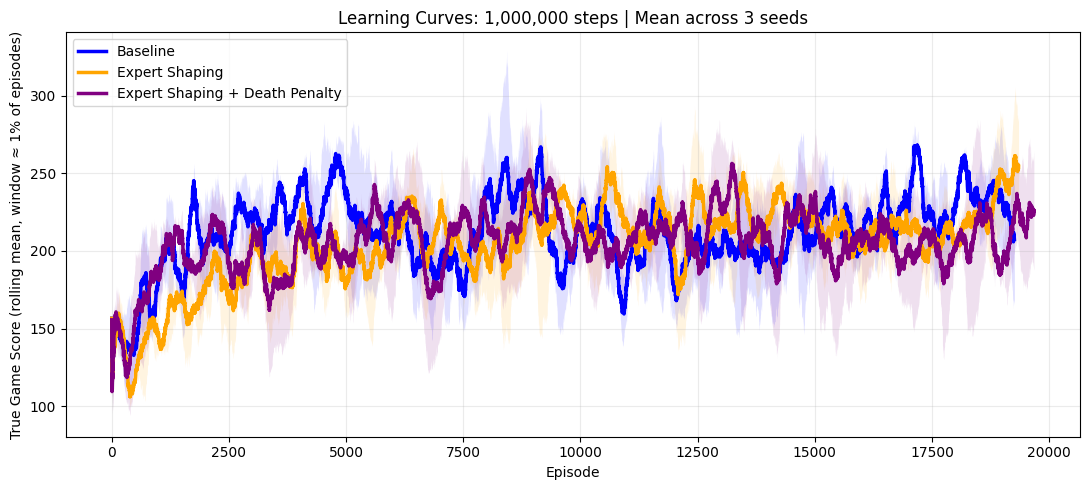


Threshold analysis — 1M


,threshold (mean),eps to threshold (mean),steps to threshold (mean),seeds reached,final train avg,eval score (mean)
Baseline,164.1,342.0,"15,980",3/3,205.1,171.2
Expert Shaping,196.7,625.0,"29,597",3/3,245.9,145.8
Expert Shaping + Death Penalty,184.0,632.0,"29,222",3/3,230.0,125.2



GAMEPLAY BEHAVIOUR — 1M steps

Gameplay metrics — 1M aggregated clean evaluation


,Mean Score,Std (ep),Median Score,Max Score,Min Score,Survival,Std Survival,Ghost Chain,Ghosts/ep,Score/step
Baseline,171.2,146.4,170.0,930.0,0.0,46.9,21.4,0.03,0.0,3.285
Expert Shaping,145.8,128.9,130.0,460.0,0.0,44.3,14.2,0.04,0.0,3.112
Expert Shaping + Death Penalty,125.2,152.4,75.0,930.0,0.0,45.9,24.7,0.03,0.0,2.261


C:\Users\traan\AppData\Local\Temp\ipykernel_12912\3899804242.py:491: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


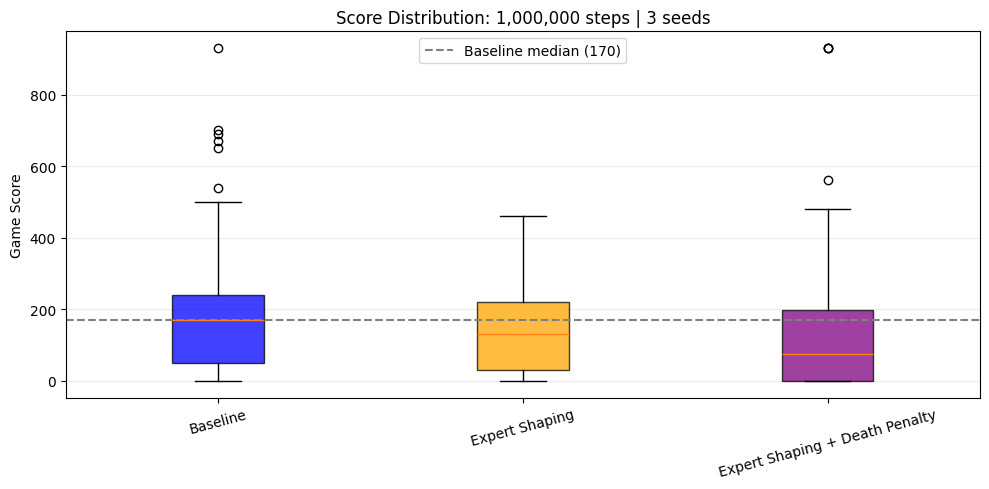


INTERPRETATION — 1M steps

Comparison vs Baseline — 1M


,Score Diff,Beats BL?,Survival Diff,Survival Dir,Train Avg
Baseline,0.0,NO,0.0,=,205.1
Expert Shaping,-25.4,NO,-2.6,-,245.9
Expert Shaping + Death Penalty,-46.0,NO,-0.9,=,230.0



Train reward vs clean evaluation — 1M


,Train Reward,Eval Score,Ratio,vs BL,Verdict
Baseline,205.1,171.2,0.83,0.0,Reference
Expert Shaping,245.9,145.8,0.59,-25.4,Possible mismatch
Expert Shaping + Death Penalty,230.0,125.2,0.54,-46.0,Possible mismatch


C:\Users\traan\AppData\Local\Temp\ipykernel_12912\3899804242.py:470: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()



LEARNING EFFICIENCY — 3M single seed indicative


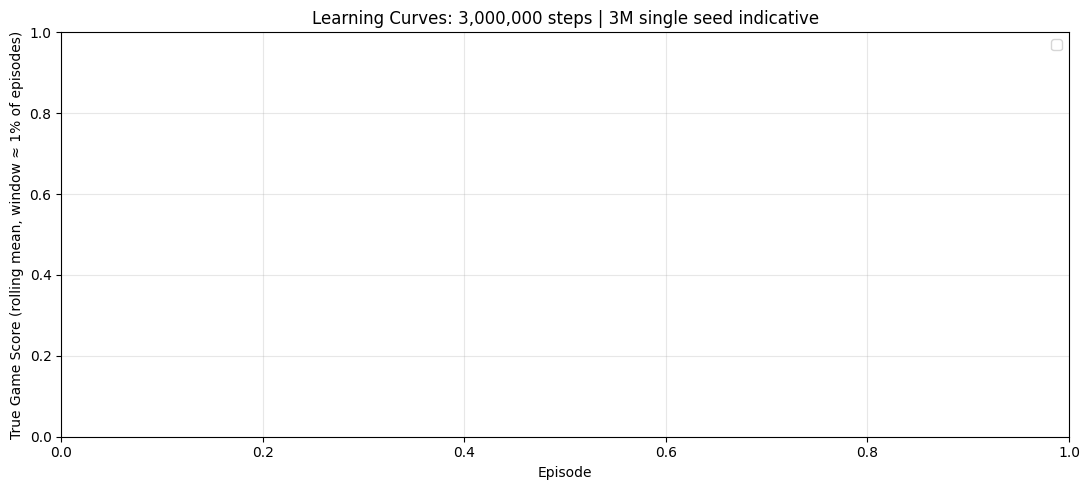


Threshold analysis — 3M single seed indicative


""



GAMEPLAY BEHAVIOUR — 3M single seed indicative

Gameplay metrics — 3M single seed indicative


""



INTERPRETATION — 3M single seed indicative

Comparison vs Baseline — 3M single seed indicative


""



Train reward vs clean evaluation — 3M single seed indicative


""



LEARNING EFFICIENCY — 7M single seed indicative


C:\Users\traan\AppData\Local\Temp\ipykernel_12912\3899804242.py:470: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


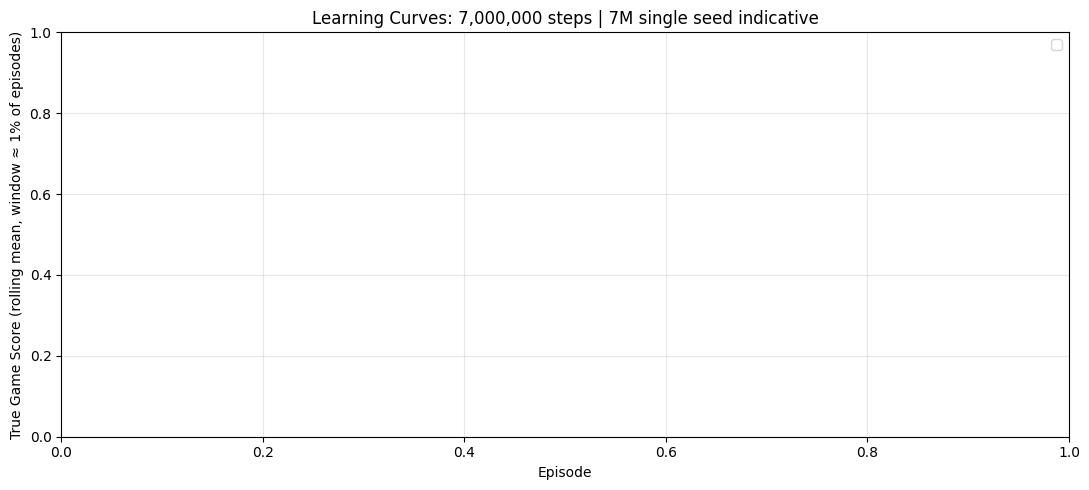


Threshold analysis — 7M single seed indicative


""



GAMEPLAY BEHAVIOUR — 7M single seed indicative

Gameplay metrics — 7M single seed indicative


""



INTERPRETATION — 7M single seed indicative

Comparison vs Baseline — 7M single seed indicative


""



Train reward vs clean evaluation — 7M single seed indicative


""



REPORT OUTPUT COMPLETE


In [ ]:
#1M multi-seed
print("=" * 62)
print("Loading 1M multi-seed results")
results_multiseed  = {name: [] for name in CONDITIONS}
eval_results_multiseed = {name: [] for name in CONDITIONS}

for name, slug in NAME_TO_SLUG.items():
    for seed in SEED_SHORT:
        steps_str    = "1M"
        model_path   = f"ppo_pacman_{slug}_{steps_str}_seed{seed}"
        training_path = f"training_{slug}_{steps_str}_seed{seed}.json"
        eval_path    = f"eval_{slug}_{steps_str}_seed{seed}.json"

        try:
            model = PPO.load(model_path)
            print(f"  Loaded {model_path}.zip")
        except FileNotFoundError:
            print(f"  {model_path}.zip not found — skipping {name} seed {seed}")
            results_multiseed[name].append(None)
            continue

        if os.path.exists(eval_path):
            er = load_eval(eval_path)
            print(f"    Eval loaded from cache: {eval_path}")
        else:
            er = evaluate_agent(model, n_episodes=100, seed=99)
            with open(eval_path, "w") as f:
                json.dump(
                    {k: v.tolist() for k, v in er.items()} |
                    {"condition": name, "steps": TOTAL_STEPS_SHORT, "seed": seed},
                    f,
                )
            print(f"    Eval complete + saved: {eval_path}")

        eval_results_multiseed[name].append({"seed": seed, **er})
        run = load_training_log(training_path, TOTAL_STEPS_SHORT, model)
        run["seed"] = seed
        results_multiseed[name].append(run)

#Rebuild 1M aggregated eval dict
eval_results_1M_agg = {}
for name in CONDITIONS:
    seed_evals = [e for e in eval_results_multiseed[name] if e is not None]
    if not seed_evals:
        continue
    eval_results_1M_agg[name] = {
        "scores":         np.concatenate([e["scores"]         for e in seed_evals]),
        "lengths":        np.concatenate([e["lengths"]        for e in seed_evals]),
        "ghost_chains":   np.concatenate([e["ghost_chains"]   for e in seed_evals]),
        "ghosts_eaten":   np.concatenate([e["ghosts_eaten"]   for e in seed_evals]),
        "score_per_step": np.concatenate([e["score_per_step"] for e in seed_evals]),
    }

# Rebuild train_final_1M
train_final_1M = {}
for name in CONDITIONS:
    valid = [r for r in results_multiseed[name] if r is not None]
    if valid:
        per_seed = [
            float(np.mean(r["episode_rewards"][-100:]))
            if len(r["episode_rewards"]) >= 100
            else float(np.mean(r["episode_rewards"]))
            for r in valid
        ]
        train_final_1M[name] = float(np.mean(per_seed))

#3M single seed 
print("\n" + "=" * 62)
print("Loading 3M single-seed results (indicative)")
results_mid    = {}
eval_results_mid = {}

for name, slug in NAME_TO_SLUG.items():
    steps_str     = "3M"
    model_path    = f"ppo_pacman_{slug}_{steps_str}_seed{SEED_MID}"
    training_path = f"training_{slug}_{steps_str}_seed{SEED_MID}.json"
    eval_path     = f"eval_{slug}_{steps_str}_seed{SEED_MID}.json"

    try:
        model = PPO.load(model_path)
        print(f"  Loaded {model_path}.zip")
    except FileNotFoundError:
        print(f"  {model_path}.zip not found — skipping {name}")
        results_mid[name] = None
        continue

    if os.path.exists(eval_path):
        er = load_eval(eval_path)
        print(f"    Eval loaded from cache: {eval_path}")
    else:
        er = evaluate_agent(model, n_episodes=100, seed=99)
        with open(eval_path, "w") as f:
            json.dump(
                {k: v.tolist() for k, v in er.items()} |
                {"condition": name, "steps": TOTAL_STEPS_MID, "seed": SEED_MID},
                f,
            )
        print(f"    Eval complete + saved: {eval_path}")

    eval_results_mid[name] = er
    results_mid[name] = load_training_log(training_path, TOTAL_STEPS_MID, model)

#7M single seed
print("\n" + "=" * 62)
print("Loading 7M single-seed results (indicative)")
results_long    = {}
eval_results_long = {}

for name, slug in NAME_TO_SLUG.items():
    steps_str     = "7M"
    model_path    = f"ppo_pacman_{slug}_{steps_str}_seed{SEED_LONG}"
    training_path = f"training_{slug}_{steps_str}_seed{SEED_LONG}.json"
    eval_path     = f"eval_{slug}_{steps_str}_seed{SEED_LONG}.json"

    try:
        model = PPO.load(model_path)
        print(f"  Loaded {model_path}.zip")
    except FileNotFoundError:
        print(f"  {model_path}.zip not found — skipping {name}")
        results_long[name] = None
        continue

    if os.path.exists(eval_path):
        er = load_eval(eval_path)
        print(f"    Eval loaded from cache: {eval_path}")
    else:
        er = evaluate_agent(model, n_episodes=100, seed=99)
        with open(eval_path, "w") as f:
            json.dump(
                {k: v.tolist() for k, v in er.items()} |
                {"condition": name, "steps": TOTAL_STEPS_LONG, "seed": SEED_LONG},
                f,
            )
        print(f"    Eval complete + saved: {eval_path}")

    eval_results_long[name] = er
    results_long[name] = load_training_log(training_path, TOTAL_STEPS_LONG, model)

#Helpers
def _last_mean(values, n=100):
    if values is None or len(values) == 0:
        return float("nan")
    values = np.array(values, dtype=float)
    return float(np.mean(values[-n:])) if len(values) >= n else float(np.mean(values))

def _train_avg_single(results_dict):
    out = {}
    for name, run in results_dict.items():
        if run is None:
            continue
        rewards = run.get("episode_shaped_rewards", run.get("episode_rewards", []))
        out[name] = _last_mean(rewards)
    return out

def _train_avg_multiseed(results_ms):
    out = {}
    for name, seed_runs in results_ms.items():
        valid = [r for r in seed_runs if r is not None]
        if not valid:
            continue
        vals = []
        for run in valid:
            rewards = run.get("episode_shaped_rewards", run.get("episode_rewards", []))
            vals.append(_last_mean(rewards))
        out[name] = float(np.mean(vals))
    return out

def _score_per_step(er):
    if "score_per_step" in er:
        return er["score_per_step"]
    scores = np.array(er["scores"], dtype=float)
    lengths = np.array(er["lengths"], dtype=float)
    return scores / np.maximum(lengths, 1)

def _eval_summary(eval_res):
    return pd.DataFrame({
        name: {
            "Mean Score":    round(float(np.mean(er["scores"])), 1),
            "Std (ep)":      round(float(np.std(er["scores"])), 1),
            "Median Score":  round(float(np.median(er["scores"])), 1),
            "Max Score":     round(float(np.max(er["scores"])), 1),
            "Min Score":     round(float(np.min(er["scores"])), 1),
            "Survival":      round(float(np.mean(er["lengths"])), 1),
            "Std Survival":  round(float(np.std(er["lengths"])), 1),
            "Ghost Chain":   round(float(np.mean(er["ghost_chains"])), 2),
            "Ghosts/ep":     round(float(np.mean(er["ghosts_eaten"])), 1),
            "Score/step":    round(float(np.mean(_score_per_step(er))), 3),
        }
        for name, er in eval_res.items()
        if name in CONDITIONS
    }).T

def _baseline_comparison(eval_res, train_finals):
    if "Baseline" not in eval_res:
        return pd.DataFrame()

    b_score  = float(np.mean(eval_res["Baseline"]["scores"]))
    b_length = float(np.mean(eval_res["Baseline"]["lengths"]))

    return pd.DataFrame({
        name: {
            "Score Diff": round(float(np.mean(er["scores"])) - b_score, 1),
            "Beats BL?":  "YES" if float(np.mean(er["scores"])) > b_score else "NO",
            "Survival Diff": round(float(np.mean(er["lengths"])) - b_length, 1),
            "Survival Dir": (
                "+" if float(np.mean(er["lengths"])) - b_length > 1 else
                "-" if float(np.mean(er["lengths"])) - b_length < -1 else
                "="
            ),
            "Train Avg": round(train_finals.get(name, float("nan")), 1),
        }
        for name, er in eval_res.items()
        if name in CONDITIONS
    }).T

def _reward_transfer_table(eval_res, train_finals):
    if "Baseline" not in eval_res:
        return pd.DataFrame()
    b_eval = float(np.mean(eval_res["Baseline"]["scores"]))
    rows = {}
    for name, er in eval_res.items():
        if name not in CONDITIONS:
            continue
        t = float(train_finals.get(name, float("nan")))
        e = float(np.mean(er["scores"]))
        ratio = round(e / t, 2) if t > 0 else float("nan")
        if name == "Baseline":
            verdict = "Reference"
        elif t > train_finals.get("Baseline", float("nan")) and e < b_eval and ratio < 0.6:
            verdict = "Possible mismatch"
        elif t > train_finals.get("Baseline", float("nan")) and e < b_eval:
            verdict = "Weak transfer"
        elif e < b_eval:
            verdict = "Underperforms"
        else:
            verdict = "No clear mismatch"
        rows[name] = {
            "Train Reward": round(t, 1),
            "Eval Score":   round(e, 1),
            "Ratio":        ratio,
            "vs BL":        round(e - b_eval, 1),
            "Verdict":      verdict,
        }
    return pd.DataFrame(rows).T

def _threshold_single_run(run, threshold_frac=0.80):
    rewards = np.array(run.get("episode_rewards", []), dtype=float)
    lengths = np.array(run.get("episode_lengths", []), dtype=float)
    if len(rewards) == 0:
        return {
            "threshold": float("nan"),
            "eps_to_threshold": float("nan"),
            "steps_to_threshold": float("nan"),
            "reached": False,
        }
    final_avg = _last_mean(rewards)
    threshold = final_avg * threshold_frac
    window = max(1, int(len(rewards) * 0.01))
    rolling = pd.Series(rewards).rolling(window, min_periods=1).mean().values
    reached_idx = np.where(rolling >= threshold)[0]
    if len(reached_idx) == 0:
        return {
            "threshold": threshold,
            "eps_to_threshold": float("nan"),
            "steps_to_threshold": float("nan"),
            "reached": False,
        }
    ep_idx = int(reached_idx[0])
    if len(lengths) > ep_idx:
        steps = int(np.sum(lengths[:ep_idx + 1]))
    else:
        steps = int(ep_idx)
    return {
        "threshold": threshold,
        "eps_to_threshold": ep_idx + 1,
        "steps_to_threshold": steps,
        "reached": True,
    }

def threshold_analysis_multiseed(results_ms, train_finals, eval_res, threshold_frac=0.80):
    rows = {}
    for name, seed_runs in results_ms.items():
        valid = [r for r in seed_runs if r is not None]
        if not valid:
            continue
        stats = [_threshold_single_run(r, threshold_frac) for r in valid]
        reached = [s for s in stats if s["reached"]]
        rows[name] = {
            "threshold (mean)": round(float(np.nanmean([s["threshold"] for s in stats])), 1),
            "eps to threshold (mean)": round(float(np.nanmean([s["eps_to_threshold"] for s in reached])), 1) if reached else float("nan"),
            "steps to threshold (mean)": f"{int(np.nanmean([s['steps_to_threshold'] for s in reached])):,}" if reached else "N/A",
            "seeds reached": f"{len(reached)}/{len(valid)}",
            "final train avg": round(train_finals.get(name, float("nan")), 1),
            "eval score (mean)": round(float(np.mean(eval_res[name]["scores"])), 1) if name in eval_res else float("nan"),
        }
    return pd.DataFrame(rows).T

def threshold_analysis_single(results_dict, train_finals, eval_res, threshold_frac=0.80):
    rows = {}
    for name, run in results_dict.items():
        if run is None:
            continue
        s = _threshold_single_run(run, threshold_frac)
        rows[name] = {
            "threshold": round(float(s["threshold"]), 1),
            "eps to threshold": int(s["eps_to_threshold"]) if s["reached"] else "N/A",
            "steps to threshold": f"{int(s['steps_to_threshold']):,}" if s["reached"] else "N/A",
            "reached?": "YES" if s["reached"] else "NO",
            "final train avg": round(train_finals.get(name, float("nan")), 1),
            "eval score": round(float(np.mean(eval_res[name]["scores"])), 1) if name in eval_res else float("nan"),
        }
    return pd.DataFrame(rows).T

#Graphs
def plot_learning_curves_multiseed(results_ms, CONDITIONS, total_steps):
    fig, ax = plt.subplots(figsize=(11, 5))
    for name, seed_runs in results_ms.items():
        valid = [r for r in seed_runs if r is not None]
        if not valid:
            continue
        color = CONDITIONS[name]["color"]
        smoothed = []
        for run in valid:
            rewards = run["episode_rewards"]
            window = max(1, int(len(rewards) * 0.01))
            s = pd.Series(rewards).rolling(window, min_periods=1).mean().values
            smoothed.append(s)
        min_len = min(len(s) for s in smoothed)
        arr = np.array([s[:min_len] for s in smoothed])
        mean_curve = arr.mean(axis=0)
        std_curve = arr.std(axis=0)
        x = np.arange(min_len)
        ax.plot(
            x,
            mean_curve,
            color=color,
            linewidth=2.5,
            label=name,
        )
        ax.fill_between(
            x,
            mean_curve - std_curve,
            mean_curve + std_curve,
            color=color,
            alpha=0.12,
            linewidth=0,
        )
        
    ax.set_xlabel("Episode")
    ax.set_ylabel("True Game Score (rolling mean, window ≈ 1% of episodes)")
    ax.set_title(f"Learning Curves: {total_steps:,} steps | Mean across 3 seeds")
    ax.legend()
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(f"plot_learning_curves_{total_steps // 1_000_000}M_multiseed_clean.png",dpi=160)

    plt.show()

def plot_learning_curves_single(res_dict, CONDITIONS, total_steps, suffix=""):
    fig, ax = plt.subplots(figsize=(11, 5))

    for name, data in res_dict.items():
        if data is None:
            continue

        rewards = data["episode_rewards"]
        window = max(1, int(len(rewards) * 0.01))
        s = pd.Series(rewards).rolling(window, min_periods=1).mean()

        ax.plot(
            s,
            color=CONDITIONS[name]["color"],
            linewidth=2,
            label=name,
        )

    ax.set_xlabel("Episode")
    ax.set_ylabel("True Game Score (rolling mean, window ≈ 1% of episodes)")
    ax.set_title(f"Learning Curves: {total_steps:,} steps{suffix}")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()

    fig.savefig(
        f"plot_learning_curves_{total_steps // 1_000_000}M.png",
        dpi=160,
    )

    plt.show()

def plot_score_distribution(eval_res, CONDITIONS, total_steps, suffix=""):
    names = [name for name in CONDITIONS if name in eval_res]
    scores = [eval_res[name]["scores"] for name in names]

    if not scores:
        return

    fig, ax = plt.subplots(figsize=(10, 5))

    bp = ax.boxplot(
        scores,
        labels=names,
        patch_artist=True,
        showfliers=True,
    )

    for patch, name in zip(bp["boxes"], names):
        patch.set_facecolor(CONDITIONS[name]["color"])
        patch.set_alpha(0.75)

    if "Baseline" in eval_res:
        baseline_median = float(np.median(eval_res["Baseline"]["scores"]))
        ax.axhline(
            baseline_median,
            linestyle="--",
            linewidth=1.5,
            color="gray",
            label=f"Baseline median ({baseline_median:.0f})",
        )
        ax.legend()

    ax.set_ylabel("Game Score")
    ax.set_title(f"Score Distribution: {total_steps:,} steps{suffix}")
    ax.grid(axis="y", alpha=0.25)
    plt.xticks(rotation=15)
    fig.tight_layout()

    fig.savefig(
        f"plot_score_distribution_{total_steps // 1_000_000}M.png",
        dpi=160,
    )

    plt.show()

# Tables and report output 
def print_learning_efficiency_1M():
    print("\n" + "=" * 62)
    print("LEARNING EFFICIENCY — 1M steps")
    plot_learning_curves_multiseed(results_multiseed, CONDITIONS, TOTAL_STEPS_SHORT)

    print("\nThreshold analysis — 1M")
    display(threshold_analysis_multiseed(
        results_multiseed,
        train_final_1M,
        eval_results_1M_agg,
        threshold_frac=0.80,
    ))

def print_gameplay_behaviour_1M():
    print("\n" + "=" * 62)
    print("GAMEPLAY BEHAVIOUR — 1M steps")

    print("\nGameplay metrics — 1M aggregated clean evaluation")
    display(_eval_summary(eval_results_1M_agg))

    plot_score_distribution(
        eval_results_1M_agg,
        CONDITIONS,
        TOTAL_STEPS_SHORT,
        suffix=" | 3 seeds",
    )

def print_interpretation_1M():
    print("\n" + "=" * 62)
    print("INTERPRETATION — 1M steps")

    print("\nComparison vs Baseline — 1M")
    display(_baseline_comparison(eval_results_1M_agg, train_final_1M))

    print("\nTrain reward vs clean evaluation — 1M")
    display(_reward_transfer_table(eval_results_1M_agg, train_final_1M))

def print_learning_efficiency_single(label, results_dict, eval_res, train_finals, total_steps):
    print("\n" + "=" * 62)
    print(f"LEARNING EFFICIENCY — {label}")
    plot_learning_curves_single(
        results_dict,
        CONDITIONS,
        total_steps,
        suffix=f" | {label}",
    )

    print(f"\nThreshold analysis — {label}")
    display(threshold_analysis_single(
        results_dict,
        train_finals,
        eval_res,
        threshold_frac=0.80,
    ))

def print_gameplay_behaviour_single(label, eval_res, total_steps):
    print("\n" + "=" * 62)
    print(f"GAMEPLAY BEHAVIOUR — {label}")

    print(f"\nGameplay metrics — {label}")
    display(_eval_summary(eval_res))

    plot_score_distribution(
        eval_res,
        CONDITIONS,
        total_steps,
        suffix=f" | {label}",
    )

def print_interpretation_single(label, eval_res, train_finals):
    print("\n" + "=" * 62)
    print(f"INTERPRETATION — {label}")

    print(f"\nComparison vs Baseline — {label}")
    display(_baseline_comparison(eval_res, train_finals))

    print(f"\nTrain reward vs clean evaluation — {label}")
    display(_reward_transfer_table(eval_res, train_finals))


def print_per_seed_scores_1M():
    print("\n" + "=" * 62)
    print("PER-SEED MEAN EVALUATION SCORES — 1M")

    rows = {}

    for name, seed_list in eval_results_multiseed.items():
        vals = {}
        for s in seed_list:
            seed = s["seed"]
            vals[f"Seed {seed}"] = round(float(np.mean(s["scores"])), 1)
        rows[name] = vals

    display(pd.DataFrame(rows).T)


# Rebuild train averages using shaped training reward where available 
train_final_1M   = _train_avg_multiseed(results_multiseed)
train_final_mid  = _train_avg_single(results_mid)
train_final_long = _train_avg_single(results_long)


#  Print everything needed for report 
print("\n" + "=" * 62)
print("REPORT OUTPUT START")

print_per_seed_scores_1M()

print_learning_efficiency_1M()
print_gameplay_behaviour_1M()
print_interpretation_1M()

print_learning_efficiency_single(
    "3M single seed indicative",
    results_mid,
    eval_results_mid,
    train_final_mid,
    TOTAL_STEPS_MID,
)
print_gameplay_behaviour_single(
    "3M single seed indicative",
    eval_results_mid,
    TOTAL_STEPS_MID,
)
print_interpretation_single(
    "3M single seed indicative",
    eval_results_mid,
    train_final_mid,
)

print_learning_efficiency_single(
    "7M single seed indicative",
    results_long,
    eval_results_long,
    train_final_long,
    TOTAL_STEPS_LONG,
)
print_gameplay_behaviour_single(
    "7M single seed indicative",
    eval_results_long,
    TOTAL_STEPS_LONG,
)
print_interpretation_single(
    "7M single seed indicative",
    eval_results_long,
    train_final_long,
)

print("\n" + "=" * 62)
print("REPORT OUTPUT COMPLETE")
